# Accident Detection Baseline: Optical Flow Motion Analysis

## Competition Overview

This notebook provides a **baseline solution** for an accident detection competition. The goal is to detect three key aspects of traffic accidents in video footage:

1. **When** did the accident happen? (temporal detection - time in seconds)
2. **Where** did it happen? (spatial detection - location coordinates within the frame)
3. **What type** of accident was it? (classification - e.g., t-bone, rear-end, single vehicle, etc.)

## Baseline Approach: Optical Flow Motion Analysis

### The Core Idea

When vehicles collide, the motion patterns in the video change dramatically:
- **Relative velocities spike** at the moment of contact
- **Debris and vehicle rebound** create sudden motion bursts
- **Motion field changes** are visible even in low-quality footage
- These motion changes are **class-agnostic** (work for all accident types)

Optical flow measures how pixels move between consecutive frames, capturing these motion changes directly from the video without needing object detection.

### The Method

Our baseline solution addresses the temporal detection requirement through motion analysis:

1. **Compute optical flow** between consecutive frames using OpenCV's Farneback algorithm
   - This creates a 2D motion field showing how each pixel moves between frames
2. **Summarize motion per frame** by calculating the mean magnitude: $M_t = \frac{1}{HW}\sum_{x,y} \|\mathbf{u}_t(x,y)\|_2$
   - This converts the 2D flow field into a single scalar value representing overall motion intensity
   - Creates a time series of motion scores
3. **Find the change point** using Kernel Change-Point Detection (KernelCPD)
   - Identifies when the motion pattern changes most dramatically
   - The earliest significant change point is predicted as the accident moment

**Note**: This baseline only addresses temporal detection (when). For spatial detection (where) and accident type classification (what), we use simple defaults:
- **Spatial location**: Defaults to frame center (0.5, 0.5)
- **Accident type**: Defaults to "single" (most common type)

### Imports & constants

In [ ]:
import cv2
import pickle
import pandas as pd
from tqdm import tqdm
from pathlib import Path
import numpy as np
import ruptures as rpt

from joblib import Parallel, delayed

# Define paths and load video files
OPTICAL_FLOW_PATH = Path("./optical_flow.pkl")
DATASET_PATH = Path("../../dataset/real_videos")
video_paths = list((DATASET_PATH / "videos").iterdir())
metadata_df = pd.read_csv(DATASET_PATH/"test_metadata.csv", index_col="path")

### Testing Configuration

**For Development/Testing**: By default, this notebook processes a tiny subset of data (recommended for initial runs). You can tweak the `take = 2` line to set the subset size. The full (test) dataset runs for 8-12+ hours.

**For Full Submission**: Comment out or remove the `take = 2` line to process all videos in the dataset.

In [2]:
# Limit the number of videos processed for testing purposes
take = None
#take = 5 # comment out this line to run on all
video_paths = video_paths[:(take or len(video_paths))]

## Step 1: Computing Optical Flow Scores

### What We're Doing

In this step, we compute **optical flow** between consecutive frames to measure motion intensity. Optical flow tracks how pixels move between frames, creating a motion field that captures vehicle movements, debris, and collision dynamics.

### How It Works

1. **Frame sampling**: If the video has higher FPS than `TARGET_FPS` (5 fps), we skip frames to reduce computation time while maintaining sufficient temporal resolution
    - **TARGET_FPS**: 5 frames per second - controls the temporal resolution. Lower values process faster but may miss brief events
2. **Optical flow calculation**: For each consecutive frame pair, we use OpenCV's `calcOpticalFlowFarneback` algorithm to compute a 2D motion field
3. **Motion magnitude**: We calculate the magnitude (speed) of motion at each pixel and compute the mean magnitude across the entire frame
4. **Motion score**: This mean magnitude becomes our motion score for that frame pair

### Output

For each video, we generate a pickle file containing:
- **Scores**: Array of mean optical flow magnitudes (one per frame pair)
- **Frames**: Frame indices corresponding to each score
- **Path**: Relative path to the video file, acting as a video id

**💡 AI Improvement Suggestions**:
- Use directional flow information (not just magnitude) to detect specific collision patterns
- Apply spatial filtering to focus on regions with high motion
- Combine with object detection to track motion of specific vehicles
- Use multi-scale optical flow for better robustness

In [3]:
# Algorithm parameters:
TARGET_FPS = 5  # Target frames per second for processing. Lower FPS = faster computation but less temporal resolution

def compute_optical_flow_score_on_frame(current_frame: cv2.typing.MatLike, previous_frame: cv2.typing.MatLike, motion_threshold: float = 0.0) -> float | None:
    """
    Computes the degree of motion between the current and previous frames.

    Args:
        current_frame (np.ndarray): Current frame in grayscale.
        previous_frame (np.ndarray): Previous frame in grayscale.
        motion_threshold (float): Threshold to filter out low-motion noise.

    Returns:
        float: A single value representing the degree of motion in the frame.
    """
    # Calculate optical flow
    flow = cv2.calcOpticalFlowFarneback(
        prev=previous_frame,
        next=current_frame,
        flow=None,
        pyr_scale=0.5,
        levels=3,
        winsize=15,
        iterations=3,
        poly_n=5,
        poly_sigma=1.2,
        flags=0,
    )

    # Compute magnitude and angle of flow vectors
    magnitude, _ = cv2.cartToPolar(flow[..., 0], flow[..., 1], angleInDegrees=True)
    magnitude = np.clip(magnitude, 0, 1e19)

    # Filter out small magnitudes (noise) using a threshold
    magnitude = magnitude[magnitude > motion_threshold]

    # Return the mean magnitude
    return magnitude.mean() if magnitude.size > 0 else 0.0

def compute_optical_flow_scores_on_video(video_path: Path) -> dict:
    """
    Process a single video file to compute optical flow at the target FPS.
    
    Args:
        video_path: source video file
    Returns:
        Dictionary containing video filename, fps, and optical flow results with their corresponding frames.
        Note there is one more frame than the optical flow scores as the optical flow is computed between two frames.
    """
    assert video_path.exists()

    cap = cv2.VideoCapture(video_path)
    original_fps = cap.get(cv2.CAP_PROP_FPS)
    
    # will use every `frame_skip`-th frame of the video
    frame_skip = int(original_fps/min(original_fps, TARGET_FPS) )

    previous_frame = None
    scores = []
    frames = []
    current_frame_idx = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        if current_frame_idx % frame_skip == 0:
            current_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            frames.append(current_frame_idx)
            if previous_frame is not None:
                scores.append(
                    compute_optical_flow_score_on_frame(current_frame, previous_frame)
                )
            previous_frame = current_frame
        current_frame_idx += 1

    cap.release()
    return {
        "path": str(video_path.relative_to(DATASET_PATH).as_posix()), 
        "scores": np.array(scores), 
        "frames": np.array(frames)
    }

In [4]:
if OPTICAL_FLOW_PATH.exists():
    print(f"Optical flow scores already computed and saved at {OPTICAL_FLOW_PATH}.")
else:
    optical_flow = Parallel(n_jobs=-1)(
        delayed(compute_optical_flow_scores_on_video)(filename) 
        for filename in tqdm(video_paths)
    )

    with open(OPTICAL_FLOW_PATH, "wb") as f:
	    pickle.dump(optical_flow, f)

Optical flow scores already computed and saved at optical_flow.pkl.


## Step 2: Temporal Detection - When Did the Accident Happen?

### The Problem

We need to identify the exact moment (frame number and time) when the accident occurred in each video.

### Our Approach: Motion Change Detection

The temporal detection process works as follows:

1. **Normalize motion scores**: Convert the optical flow scores to proportions (0-1) to make the method scale-invariant
2. **Apply Kernel Change-Point Detection**: Use the `ruptures` library's KernelCPD algorithm to find when the motion pattern changes most dramatically
3. **Return the change point**: The frame where the biggest change occurred is our predicted accident moment

### How It Works

**KernelCPD (Kernel Change-Point Detection)**: This algorithm looks for points where the statistical distribution of the data changes. In our case, it finds when the bounding box area pattern shifts (indicating collision).
We use a Radial Basis Function (RBF) kernel, which is good at detecting smooth changes in patterns.

### Output

For each video, we get:
- `accident_time`: The predicted time in seconds where the accident occurred

### Spatial and Type Defaults

This baseline only addresses temporal detection. For the other two competition requirements:
- **Spatial detection (where)**: Defaults to frame center (0.5, 0.5) - a placeholder that needs improvement
- **Accident type (what)**: Defaults to "single" (most common type) - a placeholder that needs improvement

**💡 AI Improvement Suggestions**:
- Use optical flow direction to identify collision regions for spatial detection
- Analyze motion patterns (direction, magnitude, spatial distribution) to classify accident types
- Combine with object detection to locate specific vehicles involved
- Use temporal models (LSTM, Transformer) to learn accident patterns from motion sequences

In [5]:
with open(OPTICAL_FLOW_PATH, "rb") as f:
    optical_flow = pickle.load(f)

results:dict[Path, dict] = {}
for info in optical_flow[:take or len(optical_flow)]:
    metadata = metadata_df.loc[info["path"]]
    # normalize the scores
    scores = info["scores"] / np.linalg.norm(info["scores"])

    # search for the biggest changes in the optical flow and get its frame
    changes = rpt.KernelCPD(kernel="rbf", min_size=1 if len(scores) < 8 else 2).fit_predict(scores, n_bkps=3)
    assert changes and len(changes) >= 1
    # take the middle frame/frame fraction as the optical flow is a change between two frames
    frame = (info["frames"][changes[0]] + info["frames"][changes[0]+1]) / 2
    fps = metadata["no_frames"] / metadata["duration"]
    results[info["path"]] = {"accident_time": float(frame / fps)}

## Step 3. Export `submission.csv`

Finally, its submission time. For each test video, write one row to `submission.csv` containing the predicted `accident_time` in seconds

The remaining required fields are filled with fixed default values:

- `center_x` / `center_y`: `0.5` / `0.5` (image center)
- `type: "single"`

This ensures the submission format is valid while development focuses on predicting accident timing.

**💡 This is a major area for improvement!**

In [6]:
# Put default values for center_x, center_y, and type
for path, item in results.items():
    item["center_x"] = 0.5
    item["center_y"] = 0.5
    item["type"] = "single"

results_df = pd.DataFrame([{"path": str(path), **i } for path, i in results.items()])
results_df.to_csv("output_optical_flow.csv", index=False)

results_df

,path,accident_time,center_x,center_y,type
0,videos/Z4kg2Ev3vhk_00.mp4,8.269196,0.5,0.5,single
1,videos/unS0-TLF1ao_00.mp4,1.700000,0.5,0.5,single
2,videos/UarP8qU1S-c_00.mp4,4.903797,0.5,0.5,single
3,videos/UarP8qU1S-c_01.mp4,1.809880,0.5,0.5,single
4,videos/nAXTthLfgtI_00.mp4,6.503906,0.5,0.5,single
...,...,...,...,...,...
2022,videos/987C4_UdnJE_00.mp4,0.480000,0.5,0.5,single
2023,videos/987C4_UdnJE_01.mp4,1.292121,0.5,0.5,single
2024,videos/eQvvIoDMXzY_00.mp4,3.384463,0.5,0.5,single
2025,videos/eQvvIoDMXzY_01.mp4,5.614636,0.5,0.5,single


## Bonus step: Visualization 📈

As a final step, we include a simple qualitative visualization to help interpret the baseline predictions.

What the visualization shows

- **Left panel**: the video frame at the predicted accident time, with the predicted accident location highlighted.

- **Right panel**: the evolution of the normalized overal optical flow over time, with a vertical line marking the predicted accident moment.

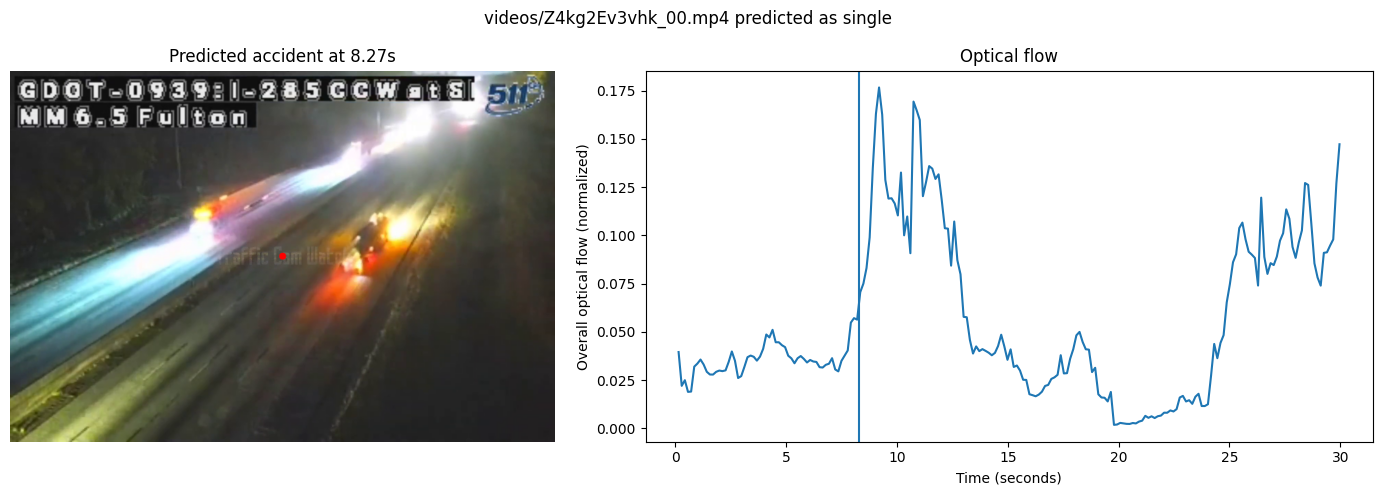

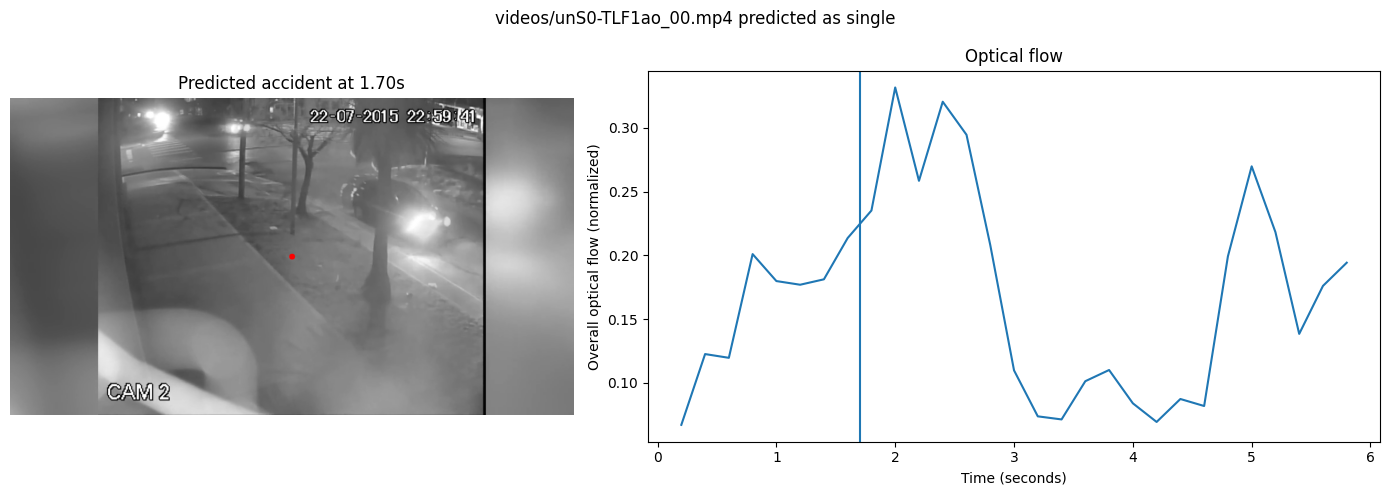

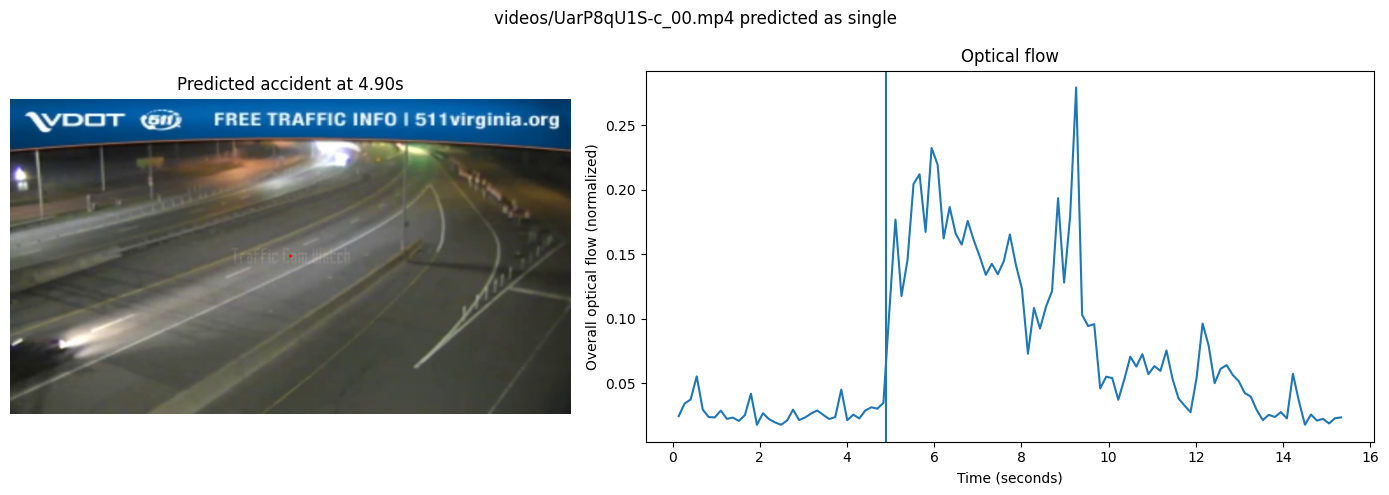

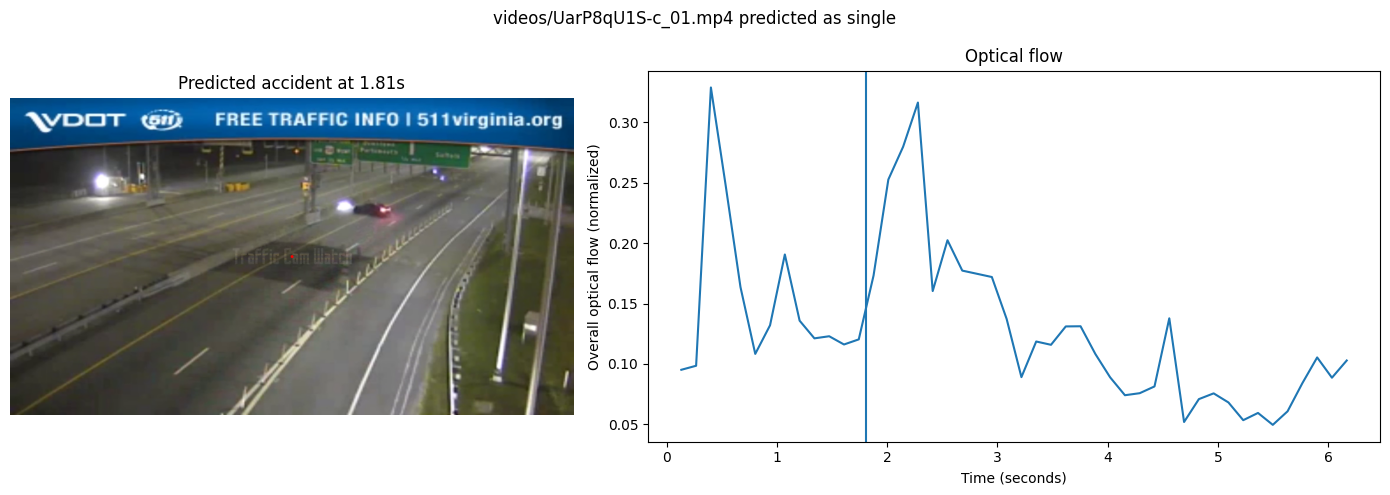

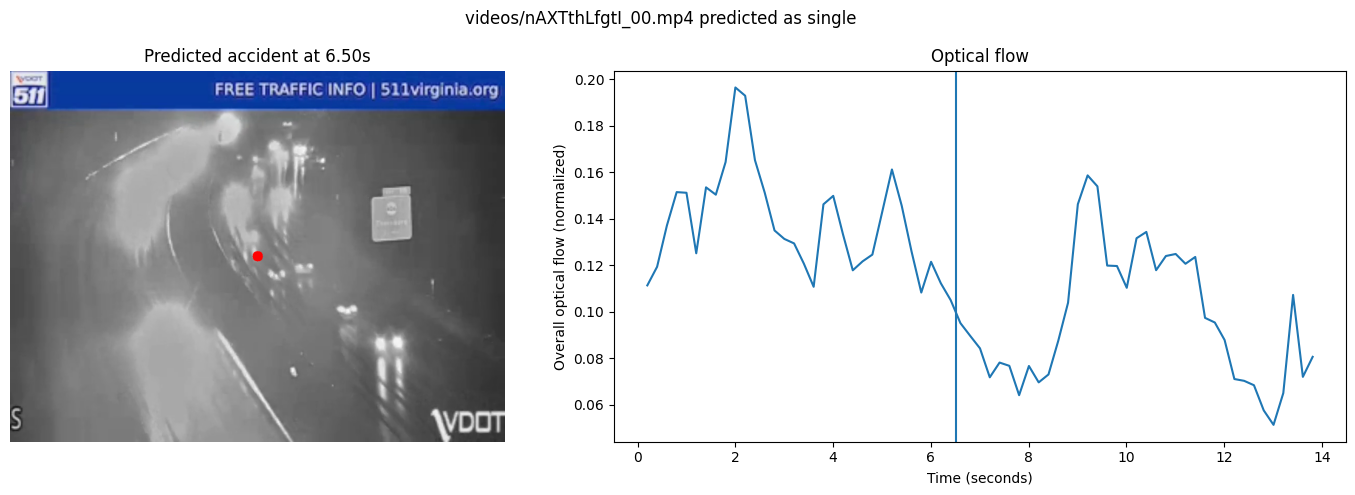

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show_video_card(
    video_path,
    values_per_frame,
    frames,
    fps,
    accident_time,
    center_x=None,
    center_y=None,
    title=None,
):
    # ---- Load accident frame ----
    cap = cv2.VideoCapture(video_path)
    frame_idx = int(accident_time * fps)
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)

    ret, frame = cap.read()
    cap.release()

    if not ret:
        raise RuntimeError(f"Could not read frame from {video_path}")

    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Optional: draw accident location
    if center_x is not None and center_y is not None:
        h, w, _ = frame.shape
        px = int(center_x * w)
        py = int(center_y * h)
        cv2.circle(frame, (px, py), 10, (255, 0, 0), -1)

    # ---- Build card ----
    fig, (ax_img, ax_plot) = plt.subplots(
        1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [1, 1.3]}
    )

    # Image panel
    ax_img.imshow(frame)
    ax_img.set_title(f"Predicted accident at {accident_time:.2f}s")
    ax_img.axis("off")

    # Signal panel
    ax_plot.plot([x/fps for x in frames[1:]], values_per_frame)
    ax_plot.axvline(accident_time)
    ax_plot.set_xlabel("Time (seconds)")
    ax_plot.set_ylabel("Overall optical flow (normalized)")
    ax_plot.set_title("Optical flow")

    if title:
        fig.suptitle(title)

    plt.tight_layout()
    plt.show()


for i, (_, row) in enumerate(results_df.iterrows()):
    if i >= (take or 5):
        break

    info = next(x for x in optical_flow if x["path"] == row["path"])
    metadata = metadata_df.loc[info["path"]]
    
    of = next(x for x in optical_flow if x["path"] == row["path"])
    show_video_card(
        video_path=DATASET_PATH / row["path"],
        values_per_frame=of["scores"] / np.linalg.norm(of["scores"]),
        frames = of["frames"],
        fps = (metadata["no_frames"] / metadata["duration"]),
        accident_time=row["accident_time"],
        center_x=row["center_x"],
        center_y=row["center_y"],
        title=f"{row['path']} predicted as {row['type']}",
    )

## Results

In [8]:
from metrics import print_temporal_accuracy

print_temporal_accuracy(results_df, DATASET_PATH)

Temporal task:
____________________
| Sigma | Accuracy |
| 0.50  | 0.140    |
| 1.00  | 0.266    |
| 2.00  | 0.466    |


